In [1]:
"""
Van der Pol oscillator simulator with broadband input.

System:
    d2y/dt2 = 2*(1 - y**2) * dy/dt - y + u(t)

Function:
    simulate_vdp(amplitude, duration, dt=0.001, fmin=0.1, fmax=50.0,
                 n_components=50, seed=None, method='RK45', input_type='sum_sine', u_func=None)

Returns:
    dict with keys:
        t   : numpy.ndarray (time vector)
        y   : numpy.ndarray (y(t))
        yd  : numpy.ndarray (dy/dt)
        u   : numpy.ndarray (input u(t) sampled at t)
        sol : scipy OdeResult (full solver result)
"""

import numpy as np
from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp
from collections.abc import Callable


def _make_broadband_sum_sine(
    amplitude: float,
    t: np.ndarray,
    fmin: float,
    fmax: float,
    n_components: int,
    seed: int | None,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    # frequencies distributed linearly between fmin and fmax
    freqs = np.linspace(fmin, fmax, n_components)
    phases = rng.uniform(0, 2 * np.pi, size=n_components)
    # random coefficients (normal) to give rich spectrum
    coeffs = rng.normal(scale=1.0, size=n_components)
    # construct sum of sines
    tt = t[:, None]  # shape (len(t), n_components)
    sin_terms = np.sin(2 * np.pi * freqs[None, :] * tt + phases[None, :])
    u_raw = (sin_terms * coeffs[None, :]).sum(axis=1)
    max_abs = np.max(np.abs(u_raw))
    if max_abs == 0:
        return np.zeros_like(u_raw)
    return amplitude * (u_raw / max_abs)


def simulate_vdp(
    amplitude: float,
    duration: float,
    dt: float = 0.001,
    fmin: float = 0.1,
    fmax: float = 50.0,
    n_components: int = 50,
    seed: int | None = None,
    method: str = "RK45",
    input_type: str = "sum_sine",
    u_func: Callable[[float], float] | None = None,
) -> dict:
    """
    Simulate Van der Pol oscillator with zero initial conditions.

    Parameters
    ----------
    amplitude : float
        Maximum absolute amplitude for u(t). The generated input will be scaled to lie in [-amplitude, amplitude].
    duration : float
        Simulation time in seconds (t from 0 to duration).
    dt : float, optional
        Time step for output sampling (default 0.001).
    fmin, fmax : float, optional
        Minimum and maximum frequency (Hz) used for the broadband input (only used for generated inputs).
    n_components : int, optional
        Number of sinusoidal components when using 'sum_sine' input_type.
    seed : int | None, optional
        RNG seed for reproducible inputs.
    method : str, optional
        ODE solver method passed to scipy.integrate.solve_ivp (default 'RK45').
    input_type : str, optional
        Type of generated input when u_func is None. Supported: 'sum_sine' (default).
    u_func : callable(t) -> float, optional
        If provided, this function is used as the input u(t) (overrides input_type). It must accept a scalar t.

    Returns
    -------
    dict
        {'t': t, 'y': y, 'yd': yd, 'u': u, 'sol': sol}
    """
    if duration <= 0:
        raise ValueError("duration must be positive.")
    if dt <= 0:
        raise ValueError("dt must be positive.")
    t = np.arange(0.0, duration + 1e-12, dt)

    # construct input signal u sampled at t
    if u_func is not None:
        # evaluate provided input function vectorized (support both scalar and array returns)
        u = np.array([float(u_func(float(tt))) for tt in t])
        # ensure bound: if user-provided not bounded, scale to requested amplitude
        max_abs = np.max(np.abs(u))
        if max_abs > 0:
            u = amplitude * (u / max_abs)
    else:
        if input_type == "sum_sine":
            u = _make_broadband_sum_sine(amplitude, t, fmin, fmax, n_components, seed)
        else:
            raise ValueError(f"Unsupported input_type: {input_type}")

    # interpolation for continuous-time evaluation inside ODE
    u_interp = interp1d(t, u, kind="linear", bounds_error=False)

    # ODE system: state x = [y, yd]
    def vdp_ode(t_scalar, x):
        y, yd = x
        u_t = float(u_interp(t_scalar))
        dydt = yd
        d2ydt2 = 2.0 * (1.0 - y * y) * yd - y + u_t
        return [dydt, d2ydt2]

    x0 = [0.0, 0.0]  # zero initial conditions

    # solve
    sol = solve_ivp(
        vdp_ode,
        t_span=(t[0], t[-1]),
        y0=x0,
        method=method,
        t_eval=t,
        vectorized=False,
        max_step=dt,
    )  # limit max step to dt for stability

    y = sol.y[0]
    yd = sol.y[1]

    return {"t": t, "y": y, "yd": yd, "u": u, "sol": sol}

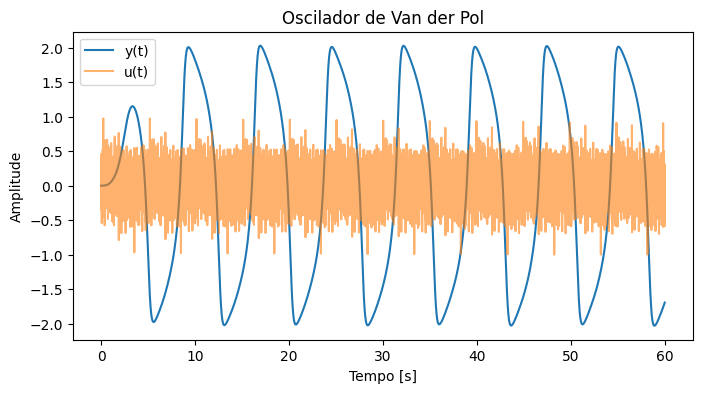

In [2]:
out = simulate_vdp(
    amplitude=1.0,
    duration=60.0,
    dt=0.001,
    fmin=0.2,
    fmax=60.0,
    n_components=100,
    seed=0,
)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(out["t"], out["y"], label="y(t)")
plt.plot(out["t"], out["u"], alpha=0.6, label="u(t)")
plt.legend()
plt.xlabel("Tempo [s]")
plt.ylabel("Amplitude")
plt.title("Oscilador de Van der Pol")
plt.savefig("resposta_oscilador.png")
plt.show()

# Série de Volterra

Uma estimativa inadequada é esperada. A representação em série de Volterra funciona bem para sistemas fracamente não lineares e com “memória evanescente”. No entanto, o oscilador de Van der Pol é um sistema auto-oscilatório que possui um ciclo limite, não a propriedade de memória evanescente em torno de sua origem instável. Com uma amplitude de entrada de 1, uma abordagem de Volterra padrão (invariante no tempo e centrada em zero) tende a ser imprecisa. Seria mais apropriado, embora mais complexo, modelar as perturbações em torno do próprio ciclo limite usando uma abordagem de Volterra variante no tempo.

Volterra estimation done (M=25, features=350).
MSE=2.0726e+00 RMSE=1.4397e+00 R2=0.0001


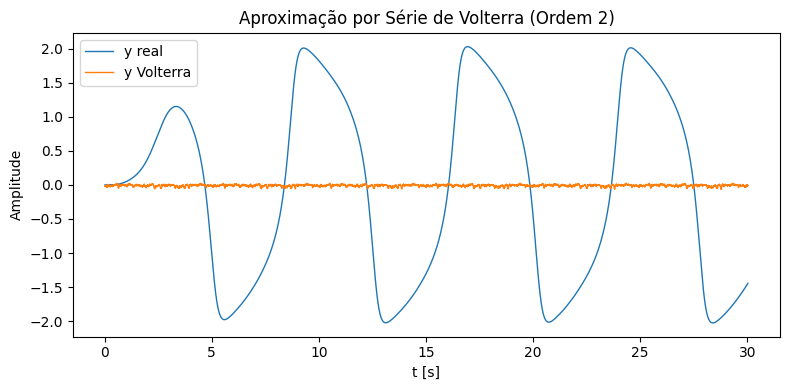

In [3]:
# Volterra series (orders 1 and 2) estimation by linear least squares.
# y[n] ≈ Σ_i h1[i] u[n-i] + Σ_{i<=j} h2[i,j] u[n-i] u[n-j]

t = out["t"]
y = out["y"]
u = out["u"]

M = 25  # memory length (number of lags)
N = len(u)
rows = N - M
if rows <= 0:
    raise ValueError("Not enough samples for chosen memory length.")

# Build lag matrix U_lag[row, lag] = u[n - lag] with n = M..N-1
U_lag = np.empty((rows, M))
for lag in range(M):
    U_lag[:, lag] = u[M - lag : N - lag]

# First-order features
features = [U_lag]

# Second-order unique lag pair features (i <= j)
second_order_pairs = []
for i in range(M):
    ui = U_lag[:, i]
    for j in range(i, M):
        second_order_pairs.append(ui * U_lag[:, j])

features.extend(second_order_pairs)

X = np.column_stack(features)
y_target = y[M:N]

# Solve least squares
coef, *_ = np.linalg.lstsq(X, y_target, rcond=None)

# Extract kernels
n_h1 = M
n_h2 = M * (M + 1) // 2
h1 = coef[:n_h1]
h2_flat = coef[n_h1 : n_h1 + n_h2]

# Build symmetric second-order kernel matrix
h2 = np.zeros((M, M))
idx = 0
for i in range(M):
    for j in range(i, M):
        h2[i, j] = h2_flat[idx]
        h2[j, i] = h2_flat[idx]
        idx += 1

# Reconstruct output (only for n >= M)
y_hat_segment = X @ coef
y_hat = np.zeros_like(y)
y_hat[M:] = y_hat_segment

mse = np.mean((y_target - y_hat_segment) ** 2)
rmse = np.sqrt(mse)
var_y = np.var(y_target)
r2 = 1.0 - mse / var_y if var_y > 0 else np.nan

print(f"Volterra estimation done (M={M}, features={X.shape[1]}).")
print(f"MSE={mse:.4e} RMSE={rmse:.4e} R2={r2:.4f}")

# Plot a short comparison segment
segment_len = 30000
start = M
end = min(M + segment_len, N)
plt.figure(figsize=(8, 4))
plt.plot(t[start:end], y[start:end], label="y real", lw=1)
plt.plot(t[start:end], y_hat[start:end], label="y Volterra", lw=1)
plt.xlabel("t [s]")
plt.ylabel("Amplitude")
plt.title("Aproximação por Série de Volterra (Ordem 2)")
plt.legend()
plt.tight_layout()
plt.savefig("aproximacao_volterra.png")
plt.show()

# Hammerstein

Geralmente, não. Um modelo de Hammerstein presume uma estrutura específica em que uma não linearidade estática atua apenas na entrada, seguida por um bloco de dinâmica linear $(u \rightarrow g(·) \rightarrow L(s) \rightarrow y)$. O oscilador de Van der Pol viola fundamentalmente essa suposição, já que sua não linearidade é interna e dependente do estado (o termo de amortecimento depende de $y$ e $\dot{y}$), e não uma simples transformação estática da entrada u. Além disso, o sistema é um auto-oscilador com um ciclo limite, o que entra em conflito com a premissa de que a dinâmica (após a não linearidade) é linear e possui memória evanescente. Por causa dessa incompatibilidade estrutural, o método de testes desacoplados provavelmente falha em encontrar um modelo válido, pois a resposta do sistema depende crucialmente de seu estado interno (como a fase no ciclo limite), algo que uma transformação estática $g(u)$ não consegue capturar.

Hammerstein estimation (poly degrees=[1, 3, 5], M=25):
a (nonlinearity coeffs): [24887898.01851437        0.                0.        ]
h (FIR) length: 25
MSE=2.0729e+00 RMSE=1.4398e+00 R2=-0.0000


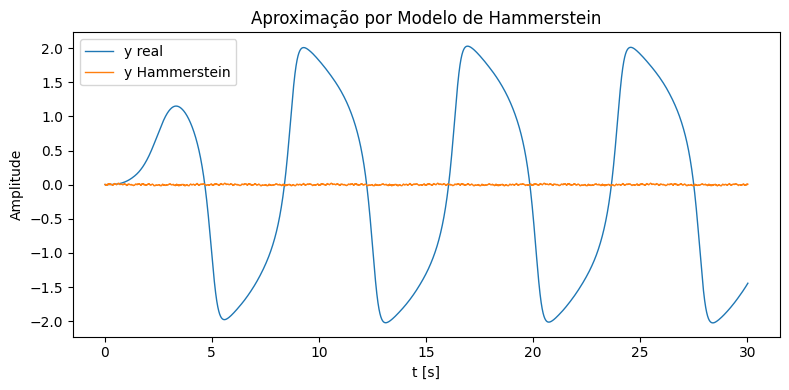

In [4]:
# Hammerstein model estimation via alternating least squares (polynomial static nonlinearity + FIR LTI)
# Uses existing variables u, y, t, and M if available.

# Use existing signals, fallback to 'out' if needed
if "u" not in globals() or "y" not in globals():
    u = out["u"]
    y = out["y"]
if "t" not in globals():
    t = out["t"]

# Memory length (reuse M if defined)
try:
    ham_M = int(M)
except NameError:
    ham_M = 25

N = len(u)
rows = N - ham_M
y_target_ham = y[ham_M:N]


def build_lag_matrix(x: np.ndarray, M: int) -> np.ndarray:
    X = np.empty((len(x) - M, M), dtype=float)
    for lag in range(M):
        X[:, lag] = x[M - lag : len(x) - lag]
    return X


# Polynomial degrees for static nonlinearity (no constant term)
ham_degs = np.array([1, 3, 5], dtype=int)
K = len(ham_degs)

# Initialize coefficients: g(u) = sum_k a_k * u^deg_k
ham_a = np.zeros(K, dtype=float)
ham_a[0] = 1.0  # start with identity nonlinearity

max_iter = 5
for _ in range(max_iter):
    # Update h given a: form v = g(u)
    ham_v = np.zeros_like(u, dtype=float)
    for k in range(K):
        ham_v += ham_a[k] * (u ** ham_degs[k])
    V_lag = build_lag_matrix(ham_v, ham_M)
    ham_h, *_ = np.linalg.lstsq(V_lag, y_target_ham, rcond=None)

    # Normalize to avoid scale ambiguity (absorb scale into a)
    h_norm = np.linalg.norm(ham_h)
    if h_norm > 0:
        ham_h /= h_norm
        ham_a *= h_norm

    # Update a given h: y ≈ sum_k a_k * (Toeplitz(u^deg_k) @ h)
    Z_cols = []
    for k in range(K):
        Wk_lag = build_lag_matrix(u ** ham_degs[k], ham_M)
        Z_cols.append(Wk_lag @ ham_h)
    Z = np.column_stack(Z_cols)
# Final prediction
ham_v = np.zeros_like(u, dtype=float)
for k in range(K):
    ham_v += ham_a[k] * (u ** ham_degs[k])
V_lag = build_lag_matrix(ham_v, ham_M)
y_hat_ham_segment = V_lag @ ham_h
V_lag = build_lag_matrix(ham_v, ham_M)
y_hat_ham_segment = V_lag @ ham_h
y_hat_ham = np.zeros_like(y)
y_hat_ham[ham_M:] = y_hat_ham_segment

# Metrics
ham_mse = float(np.mean((y_target_ham - y_hat_ham_segment) ** 2))
ham_rmse = float(np.sqrt(ham_mse))
var_y_ham = float(np.var(y_target_ham))
ham_r2 = 1.0 - ham_mse / var_y_ham if var_y_ham > 0 else np.nan

print(
    "Hammerstein estimation (poly degrees={}, M={}):".format(ham_degs.tolist(), ham_M)
)
print("a (nonlinearity coeffs):", ham_a)
print("h (FIR) length:", len(ham_h))
print(f"MSE={ham_mse:.4e} RMSE={ham_rmse:.4e} R2={ham_r2:.4f}")

# Plot a comparison segment
ham_start = ham_M
ham_end = min(ham_start + 30000, N)
plt.figure(figsize=(8, 4))
plt.plot(t[ham_start:ham_end], y[ham_start:ham_end], label="y real", lw=1)
plt.plot(
    t[ham_start:ham_end], y_hat_ham[ham_start:ham_end], label="y Hammerstein", lw=1
)
plt.xlabel("t [s]")
plt.ylabel("Amplitude")
plt.title("Aproximação por Modelo de Hammerstein")
plt.legend()
plt.tight_layout()
plt.savefig("aproximacao_hammerstein.png")
plt.show()

# Wiener

Geralmente, não. Um modelo de Wiener assume que toda a não linearidade do sistema pode ser representada por um mapa estático $g(\cdot)$ aplicado após um bloco de dinâmica linear $u \rightarrow L(s) \rightarrow w \rightarrow g(\cdot) \rightarrow y$. O oscilador de Van der Pol conflita diretamente com essa estrutura, já que sua não linearidade é interna e dependente do estado (o termo de amortecimento $(1-y^2)\dot{y}$), e não uma simples distorção estática da saída de um filtro linear. Adicionalmente, o sistema possui um ciclo limite auto-oscilatório, introduzindo uma memória de fase e dinâmicas internas que a estrutura Wiener (LTI + mapa estático) não consegue capturar. Portanto, é muito provável que os testes desacoplados falhem em encontrar um modelo válido devido a essa incompatibilidade estrutural fundamental.

Wiener estimation (M=25, degs=[1, 3, 5]).
FIR h length: 25
Poly coeffs b: [-1.33255476e+00  3.39118944e+04 -8.13728157e+07]
MSE=2.0728e+00 RMSE=1.4397e+00 R2=0.0000


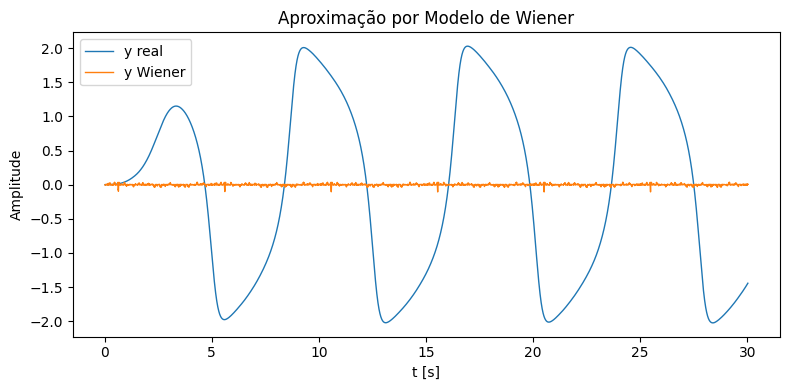

In [5]:
# Wiener model estimation (LTI FIR followed by static polynomial nonlinearity).
# Uses existing u, y, t, and M (memory length) if available.

# Reuse memory length
try:
    wiener_M = int(M)
except NameError:
    wiener_M = 25

N = len(u)
rows_w = N - wiener_M
if rows_w <= 0:
    raise ValueError("Not enough samples for chosen memory length.")

# Build lag matrix for u
U_lag_w = np.empty((rows_w, wiener_M))
for lag in range(wiener_M):
    U_lag_w[:, lag] = u[wiener_M - lag : N - lag]

y_target_w = y[wiener_M:N]

# Initial linear FIR (ignore nonlinearity)
wiener_h, *_ = np.linalg.lstsq(U_lag_w, y_target_w, rcond=None)
w_lin = U_lag_w @ wiener_h

# Static polynomial nonlinearity: y ≈ Σ b_k * w_lin**deg_k
wiener_degs = np.array([1, 3, 5], dtype=int)
Wcols = [w_lin**d for d in wiener_degs]
Wmat = np.column_stack(Wcols)
wiener_b, *_ = np.linalg.lstsq(Wmat, y_target_w, rcond=None)

# Prediction
y_hat_w_segment = Wmat @ wiener_b
y_hat_wiener = np.zeros_like(y)
y_hat_wiener[wiener_M:] = y_hat_w_segment

# Metrics
wiener_mse = float(np.mean((y_target_w - y_hat_w_segment) ** 2))
wiener_rmse = float(np.sqrt(wiener_mse))
var_y_w = float(np.var(y_target_w))
wiener_r2 = 1.0 - wiener_mse / var_y_w if var_y_w > 0 else np.nan

print(f"Wiener estimation (M={wiener_M}, degs={wiener_degs.tolist()}).")
print("FIR h length:", len(wiener_h))
print("Poly coeffs b:", wiener_b)
print(f"MSE={wiener_mse:.4e} RMSE={wiener_rmse:.4e} R2={wiener_r2:.4f}")

# Plot comparison segment
wiener_start = wiener_M
wiener_end = min(wiener_start + 30000, N)
plt.figure(figsize=(8, 4))
plt.plot(t[wiener_start:wiener_end], y[wiener_start:wiener_end], label="y real", lw=1)
plt.plot(
    t[wiener_start:wiener_end],
    y_hat_wiener[wiener_start:wiener_end],
    label="y Wiener",
    lw=1,
)
plt.xlabel("t [s]")
plt.ylabel("Amplitude")
plt.title("Aproximação por Modelo de Wiener")
plt.legend()
plt.tight_layout()
plt.savefig("aproximacao_wiener.png")
plt.show()

# NARX

Sim: um modelo NARX é uma escolha razoável e substancialmente mais flexível do que as estruturas Wiener ou Hammerstein para este sistema. A principal vantagem do NARX é usar tanto entradas passadas ($u(t-k)$) quanto saídas passadas ($y(t-k)$) como regressores, o que permite capturar dinâmicas complexas dependentes do estado. Isso é ideal para o oscilador de Van der Pol, cuja não linearidade (o amortecimento dependente do estado) é interna.

In [6]:
import numpy as np
from sklearn.neural_network import MLPRegressor


def generate_vdp_data(n_samples=50000, dt=1e-3, amp=1.0):
    """
    Generates input-output data from the Van der Pol system for NARX modeling.
    """
    t = np.arange(n_samples) * dt
    u = amp * np.random.uniform(-1, 1, size=n_samples)

    y = np.zeros(n_samples)
    dy = np.zeros(n_samples)

    for k in range(2, n_samples):
        ddy = 2 * (1 - y[k - 1] ** 2) * dy[k - 1] - y[k - 1] + u[k - 1]
        dy[k] = dy[k - 1] + dt * ddy
        y[k] = y[k - 1] + dt * dy[k]

    return u, y


def build_narx_dataset(u, y, na=4, nb=4, nk=1):
    """
    Constructs a NARX regression matrix for autoregressive order na,
    input order nb, and input delay nk.
    """
    N = len(y)
    max_k = max(na, nb + nk - 1)
    X = []
    Y = []

    for k in range(max_k, N):
        phi = []
        phi.extend(y[k - i] for i in range(1, na + 1))  # past outputs
        phi.extend(u[k - nk - i + 1] for i in range(1, nb + 1))  # past inputs
        X.append(phi)
        Y.append(y[k])

    return np.array(X), np.array(Y)


def train_narx_model(X, Y, hidden=(20, 20)):
    """
    Trains an MLP-based NARX model.
    """
    model = MLPRegressor(
        hidden_layer_sizes=hidden,
        activation="tanh",
        solver="adam",
        max_iter=2000,
        batch_size=256,
    )
    model.fit(X, Y)
    return model

In [7]:
u, y = generate_vdp_data()
X, Y = build_narx_dataset(u, y)
narx_model = train_narx_model(X, Y)

NARX estimation (na=4, nb=4, nk=1).
MSE=7.4623e-05 RMSE=8.6384e-03 R2=1.0000


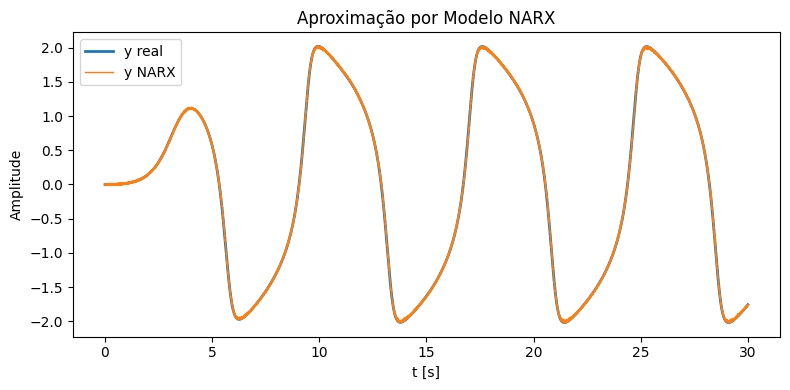

In [8]:
# Reconstruct full prediction aligned with original y (offset = max lag used in build_narx_dataset)
narx_na = 4
narx_nb = 4
narx_nk = 1
narx_offset = max(narx_na, narx_nb + narx_nk - 1)  # = 4

y_hat_narx = np.zeros_like(y)
y_pred_narx = narx_model.predict(X)
y_hat_narx[narx_offset:] = y_pred_narx

# Metrics over comparable region
y_target_narx = y[narx_offset:]
mse_narx = float(np.mean((y_target_narx - y_pred_narx) ** 2))
rmse_narx = float(np.sqrt(mse_narx))
var_y_narx = float(np.var(y_target_narx))
r2_narx = 1.0 - mse_narx / var_y_narx if var_y_narx > 0 else float("nan")

print(f"NARX estimation (na={narx_na}, nb={narx_nb}, nk={narx_nk}).")
print(f"MSE={mse_narx:.4e} RMSE={rmse_narx:.4e} R2={r2_narx:.4f}")

# Time vector for this dataset (dt used in generate_vdp_data default = 1e-3)
t_narx = np.arange(len(y)) * 1e-3

# Plot segment
narx_start = narx_offset
narx_end = min(narx_start + 30000, len(y))
plt.figure(figsize=(8, 4))
plt.plot(t_narx[narx_start:narx_end], y[narx_start:narx_end], label="y real", lw=2)
plt.plot(
    t_narx[narx_start:narx_end], y_hat_narx[narx_start:narx_end], label="y NARX", lw=1
)
plt.xlabel("t [s]")
plt.ylabel("Amplitude")
plt.title("Aproximação por Modelo NARX")
plt.legend()
plt.tight_layout()
plt.savefig("aproximacao_narx.png")
plt.show()

NARX generalization to new input: MSE=8.1530e-05 RMSE=9.0294e-03 R2=1.0000


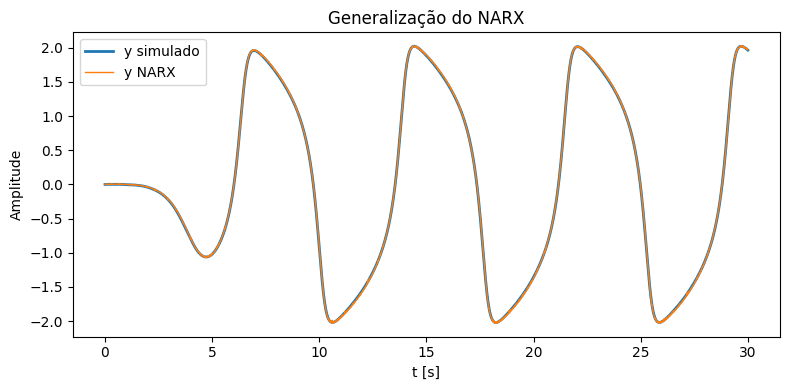

In [9]:
# Run a new simulation with a new random input realization
out_new = simulate_vdp(
    amplitude=1.0,
    duration=60.0,
    dt=0.001,
    fmin=0.2,
    fmax=60.0,
    n_components=100,
    seed=1,  # different seed for a new realization
)

u_new = out_new["u"]
y_new = out_new["y"]
t_new = out_new["t"]

# Build NARX dataset for the new input/output (use same na, nb, nk as before)
narx_na = 4
narx_nb = 4
narx_nk = 1
narx_offset = max(narx_na, narx_nb + narx_nk - 1)

X_new, Y_new = build_narx_dataset(u_new, y_new, na=narx_na, nb=narx_nb, nk=narx_nk)
y_hat_narx_new = np.zeros_like(y_new)
y_pred_narx_new = narx_model.predict(X_new)
y_hat_narx_new[narx_offset:] = y_pred_narx_new

# Metrics
y_target_narx_new = y_new[narx_offset:]
mse_new = float(np.mean((y_target_narx_new - y_pred_narx_new) ** 2))
rmse_new = float(np.sqrt(mse_new))
var_y_new = float(np.var(y_target_narx_new))
r2_new = 1.0 - mse_new / var_y_new if var_y_new > 0 else float("nan")

print(f"NARX generalization to new input: MSE={mse_new:.4e} RMSE={rmse_new:.4e} R2={r2_new:.4f}")

# Plot comparison
start = narx_offset
end = min(start + 30000, len(y_new))
plt.figure(figsize=(8, 4))
plt.plot(t_new[start:end], y_new[start:end], label="y simulado", lw=2)
plt.plot(t_new[start:end], y_hat_narx_new[start:end], label="y NARX", lw=1)
plt.xlabel("t [s]")
plt.ylabel("Amplitude")
plt.title("Generalização do NARX")
plt.legend()
plt.tight_layout()
plt.savefig("aproximacao_narx_teste.png")
plt.show()

# Efeito da Amplitude da Entrada

Entradas com amplitude menor podem permitir a identificação eficiente pelos métodos que falham para a testada. Com amplitudes menores, o sistema opera em uma região mais linearizada ao redor da origem, onde as aproximações lineares e as suposições de memória evanescente são mais válidas. Isso pode permitir que modelos como Volterra, Hammerstein ou Wiener capturem adequadamente a dinâmica do sistema, pois a não linearidade intrínseca e o comportamento do ciclo limite são menos pronunciados.

In [10]:
# Amplitude sweep: RMSE vs input amplitude for Volterra (order 2), Hammerstein, Wiener, NARX.


def volterra_rmse(u, y, M: int):
    N = len(u)
    rows = N - M
    if rows <= 0:
        return np.nan
    U_lag = np.empty((rows, M))
    for lag in range(M):
        U_lag[:, lag] = u[M - lag : N - lag]
    features = [U_lag]
    # second-order (i<=j)
    for i in range(M):
        ui = U_lag[:, i]
        for j in range(i, M):
            features.append(ui * U_lag[:, j])
    X = np.column_stack(features)
    y_target = y[M:N]
    coef, *_ = np.linalg.lstsq(X, y_target, rcond=None)
    y_hat = X @ coef
    rmse = float(np.sqrt(np.mean((y_target - y_hat) ** 2)))
    return rmse


def hammerstein_rmse(u, y, M: int, degs=(1, 3, 5), max_iter=5):
    N = len(u)
    rows = N - M
    if rows <= 0:
        return np.nan

    def lag_matrix(x):
        L = np.empty((len(x) - M, M))
        for lag in range(M):
            L[:, lag] = x[M - lag : len(x) - lag]
        return L

    y_target = y[M:N]
    degs = np.array(degs, dtype=int)
    K = len(degs)
    a = np.zeros(K)
    a[0] = 1.0
    h = np.zeros(M)
    for _ in range(max_iter):
        v = sum(a[k] * (u ** degs[k]) for k in range(K))
        V_lag = lag_matrix(v)
        h, *_ = np.linalg.lstsq(V_lag, y_target, rcond=None)
        # normalize
        norm_h = np.linalg.norm(h)
        if norm_h > 0:
            h /= norm_h
            a *= norm_h
        # update a
        cols = []
        for k in range(K):
            Wk_lag = lag_matrix(u ** degs[k])
            cols.append(Wk_lag @ h)
        Z = np.column_stack(cols)
        a, *_ = np.linalg.lstsq(Z, y_target, rcond=None)
    # final prediction
    v = sum(a[k] * (u ** degs[k]) for k in range(K))
    V_lag = lag_matrix(v)
    y_hat = V_lag @ h
    rmse = float(np.sqrt(np.mean((y_target - y_hat) ** 2)))
    return rmse


def wiener_rmse(u, y, M: int, degs=(1, 3, 5)):
    N = len(u)
    rows = N - M
    if rows <= 0:
        return np.nan
    U_lag = np.empty((rows, M))
    for lag in range(M):
        U_lag[:, lag] = u[M - lag : N - lag]
    y_target = y[M:N]
    h, *_ = np.linalg.lstsq(U_lag, y_target, rcond=None)
    w_lin = U_lag @ h
    degs = np.array(degs, dtype=int)
    W = np.column_stack([w_lin**d for d in degs])
    b, *_ = np.linalg.lstsq(W, y_target, rcond=None)
    y_hat = W @ b
    rmse = float(np.sqrt(np.mean((y_target - y_hat) ** 2)))
    return rmse


def narx_rmse(u, y, na=4, nb=4, nk=1, hidden=(20, 20), max_iter=500):
    # Build dataset from given u,y (reuse build_narx_dataset)
    X, Y = build_narx_dataset(u, y, na=na, nb=nb, nk=nk)
    if X.size == 0:
        return np.nan
    model = MLPRegressor(
        hidden_layer_sizes=hidden,
        activation="tanh",
        solver="adam",
        max_iter=max_iter,
        batch_size=256,
    )
    model.fit(X, Y)
    Y_pred = model.predict(X)
    rmse = float(np.sqrt(np.mean((Y - Y_pred) ** 2)))
    return rmse


# Sweep parameters
amplitudes = np.linspace(0.1, 1.0, 10)
M_sweep = 25
duration = 30.0  # shorter duration to limit runtime
dt = 0.001

rmse_volterra = []
rmse_hammerstein = []
rmse_wiener = []
rmse_narx = []

for amp in amplitudes:
    out_amp = simulate_vdp(
        amplitude=amp,
        duration=duration,
        dt=dt,
        fmin=0.2,
        fmax=60.0,
        n_components=60,
        seed=0,
    )
    u_sig = out_amp["u"]
    y_sig = out_amp["y"]
    # Volterra
    rmse_volterra.append(volterra_rmse(u_sig, y_sig, M_sweep))
    # Hammerstein
    rmse_hammerstein.append(hammerstein_rmse(u_sig, y_sig, M_sweep))
    # Wiener
    rmse_wiener.append(wiener_rmse(u_sig, y_sig, M_sweep))
    # NARX
    rmse_narx.append(
        narx_rmse(u_sig, y_sig, na=4, nb=4, nk=1, hidden=(15, 15), max_iter=400)
    )

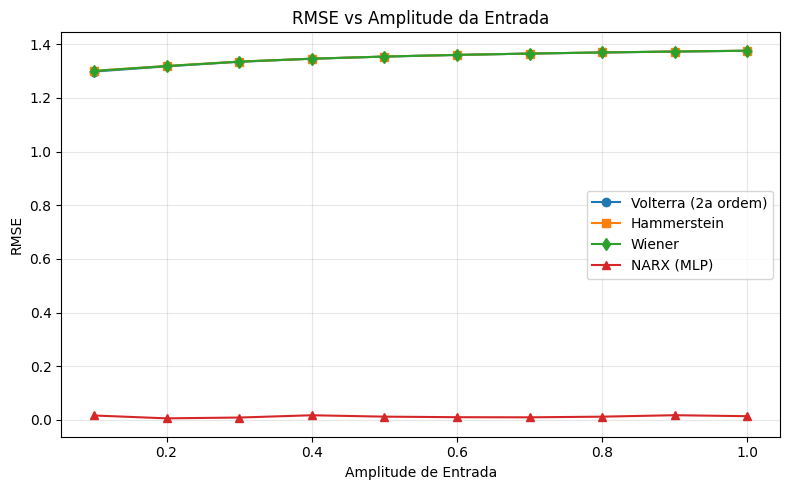

In [11]:
# Plot
plt.figure(figsize=(8, 5))
plt.plot(amplitudes, rmse_volterra, "o-", label="Volterra (2a ordem)")
plt.plot(amplitudes, rmse_hammerstein, "s-", label="Hammerstein")
plt.plot(amplitudes, rmse_wiener, "d-", label="Wiener")
plt.plot(amplitudes, rmse_narx, "^-", label="NARX (MLP)")
plt.xlabel("Amplitude de Entrada")
plt.ylabel("RMSE")
plt.title("RMSE vs Amplitude da Entrada")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("rmse_vs_amplitude.png")
plt.show()

# Resultados da Varredura de Amplitude

A varredura de amplitude refuta a hipótese de que modelos como Volterra, Hammerstein e Wiener podem capturar adequadamente a dinâmica do oscilador de Van der Pol em amplitudes menores. Mesmo em níveis de entrada reduzidos, esses modelos continuam apresentando erros significativos, indicando que suas estruturas inerentes não são adequadas para representar o comportamento do sistema. Em contraste, o modelo NARX mantém um desempenho robusto em toda a faixa de amplitudes testadas, destacando sua capacidade superior de capturar as dinâmicas complexas e dependentes do estado do sistema, independentemente da amplitude da entrada.

# Complexidade Computacional

Modelos NARX, especialmente aqueles baseados em redes neurais como MLPs, tendem a ser mais computacionalmente intensivos do que modelos de Volterra, Hammerstein ou Wiener. A complexidade do NARX aumenta com o número de regressores (ordens de entrada e saída) e a complexidade da rede (número de camadas e neurônios). Em contraste, os modelos de Volterra, Hammerstein e Wiener geralmente envolvem menos parâmetros e cálculos mais simples, resultando em tempos de treinamento e inferência mais rápidos. Portanto, embora o NARX ofereça maior flexibilidade e precisão para sistemas complexos como o oscilador de Van der Pol, isso vem ao custo de maior demanda computacional.